<a href="https://colab.research.google.com/github/Unsogoodday/sc_tutorials/blob/main/scvi_tutorials_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/Unsogoodday/sc_tutorials.git

Cloning into 'sc_tutorials'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 117 (delta 46), reused 82 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 18.19 MiB | 20.61 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [3]:
%cd /content/sc_tutorials/scanpy_practice
##%pip install -q -r requirements.txt

/content/sc_tutorials/scanpy_practice
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.6/183.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━

In [4]:
%cd /content/drive/MyDrive/01_Work/2025_Research_Prep/scvi_tutorials

/content/drive/MyDrive/01_Work/2025_Research_Prep/scvi_tutorials


In [5]:
import torch

# Single Cell Libraries
import scvi
import scanpy as sc
import anndata as ad

# Data Processing and Plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph
import leidenalg

# File grab
import os
import tempfile
import pooch

print(torch.__version__)
print(scvi.__version__)
print(torch.cuda.is_available())

2.8.0+cu126
1.3.3
True


In [6]:
# basic settings

sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [ ]:
adata = scvi.data.heart_cell_atlas_subsampled(save_path=save_dir.name)
adata

INFO     Downloading file at /tmp/tmpqbtg1czs/hca_subsampled_20k.h5ad                                              


Downloading...:   0%|          | 0/65714.0 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

In [ ]:
print(adata.X.max())

7468.0


In [ ]:
# pp
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source",
)

In [ ]:
# set up scVI

scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    categorical_covariate_keys=["cell_source", "donor"],
    continuous_covariate_keys=["percent_mito", "percent_ribo"],
)

In [ ]:
# creating and training the model\
model = scvi.model.SCVI(adata)
model.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


In [21]:
model_dir = "/content/drive/MyDrive/01_Work/2025_Research_Prep/scvi_tutorials/_Dataset"
os.makedirs(model_dir, exist_ok=True)
model.save(model_dir, save_anndata=True, overwrite=True)

In [7]:
# Check model loading
## 다음에는 바로 이걸로 한다.

adata=sc.read_h5ad("/content/drive/MyDrive/01_Work/2025_Research_Prep/scvi_tutorials/_Dataset/adata.h5ad")
model_dir = '/content/drive/MyDrive/01_Work/2025_Research_Prep/scvi_tutorials/_Dataset'
model = scvi.model.SCVI.load(model_dir, adata=adata)

INFO     File /content/drive/MyDrive/01_Work/2025_Research_Prep/scvi_tutorials/_Dataset/model.pt already downloaded


In [ ]:
# Obtain model outputs
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(18641, 10)

In [ ]:
adata_subset = adata[adata.obs.cell_type == "Fibroblast"]
latent_subset = model.get_latent_representation(adata_subset)
latent_subset.shape

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


(2446, 10)

In [ ]:
denoised = model.get_normalized_expression(adata_subset, library_size=1e4)
denoised.iloc[:5, :5]

,ISG15,TNFRSF18,VWA1,HES5,SPSB1
GTCAAGTCATGCCACG-1-HCAHeart7702879,1.786532,0.039930,1.696414,0.021971,2.440354
GAGTCATTCTCCGTGT-1-HCAHeart8287128,1.555167,0.001412,2.887688,0.026336,28.617941
CCTCTGATCGTGACAT-1-HCAHeart7702881,1.795832,0.023499,1.472212,0.098491,3.687494
CGCCATTCATCATCTT-1-H0035_apex,0.341540,0.109434,0.573863,0.017550,6.067900
TCGTAGAGTAGGACTG-1-H0015_septum,0.334354,0.148594,0.204461,0.018205,6.764916


In [ ]:
SCVI_NORMALIZED_KEY = "scvi_normalized"

adata.layers[SCVI_NORMALIZED_KEY] = model.get_normalized_expression(library_size=10e4)

In [22]:
# Save to github

%cd /content/sc_tutorials/scanpy_practice/scvi_tutorials
!git config --global user.email "242shizume@gmail.com"
!git config --global user.name "Unsogoodday"

!git add scvi-tutorials_colab.ipynb
!git commit -m "Add/update notebook from Colab"
!git push

/content/sc_tutorials/scanpy_practice/scvi_tutorials
fatal: pathspec 'scvi-tutorials_colab.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


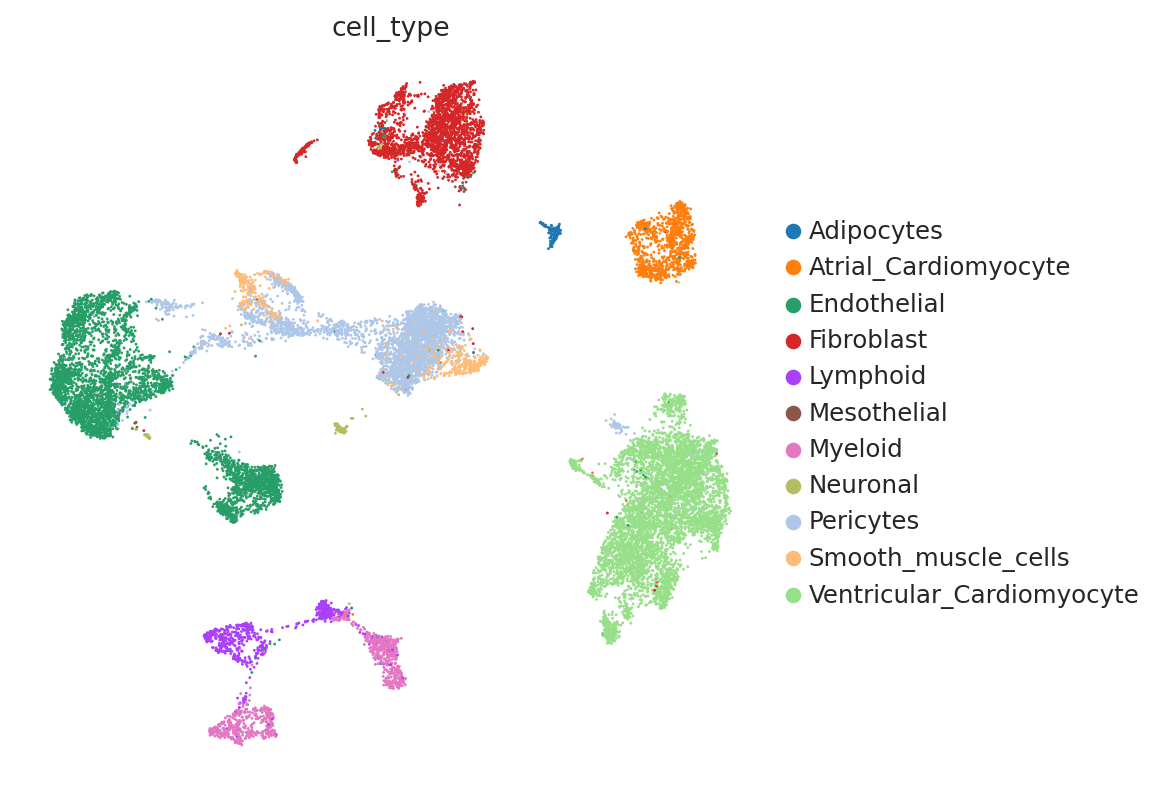

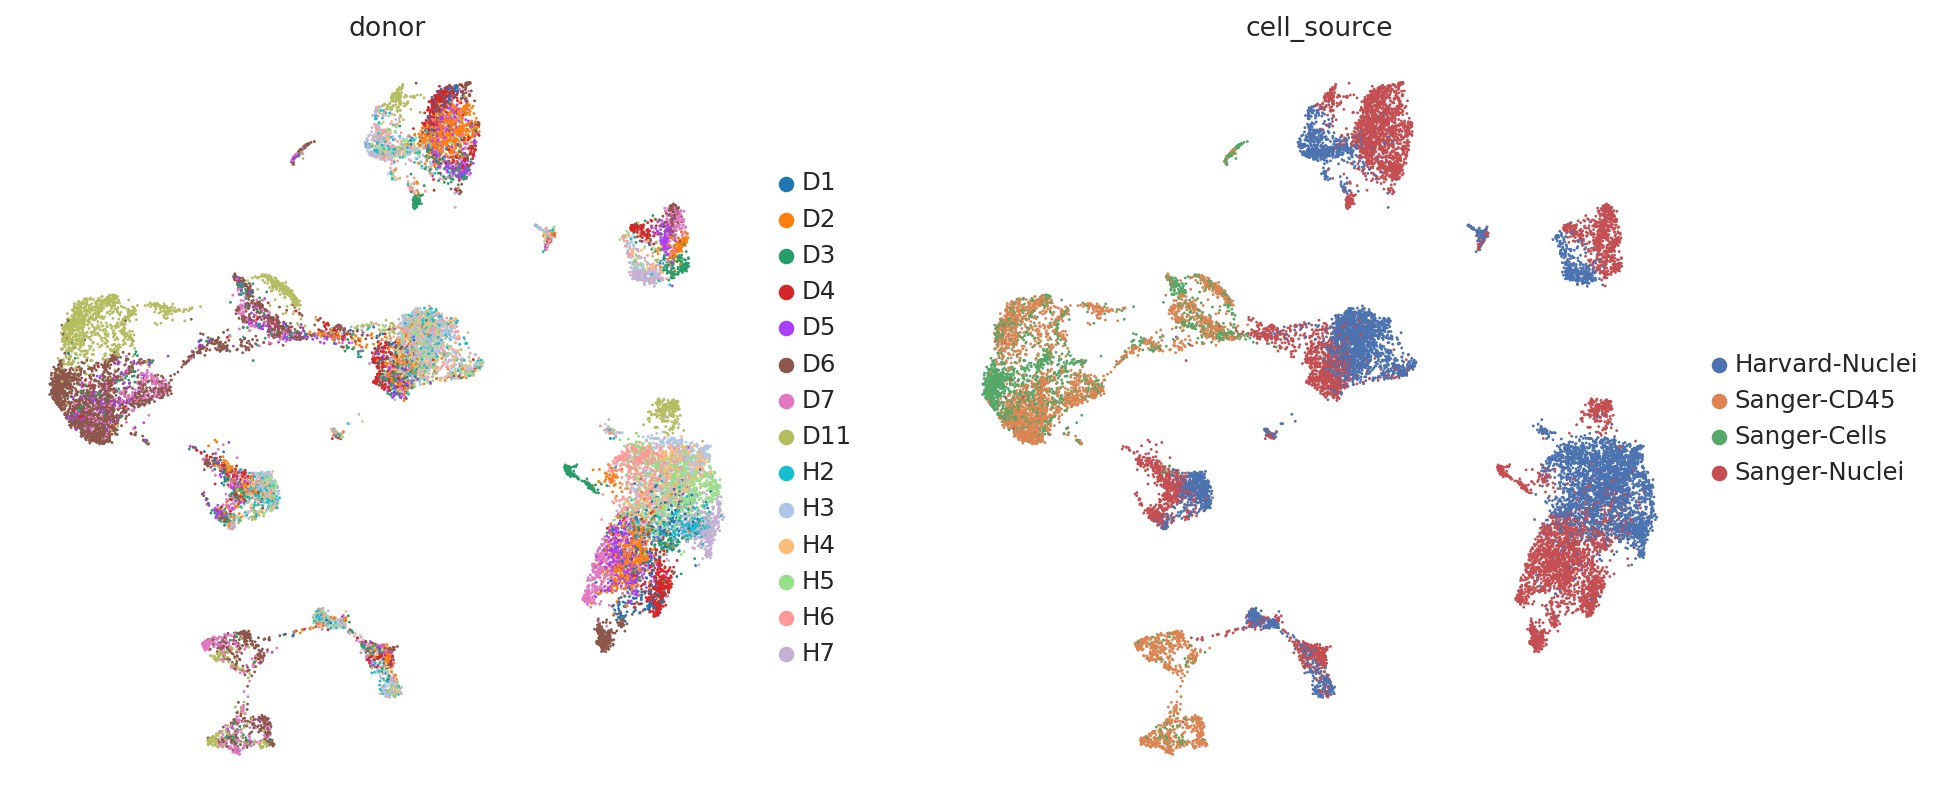

In [ ]:
# Visualization without batch correction

sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
    save="_0_celltype.png"
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
    save="_1_donor_cellsource.png"
)

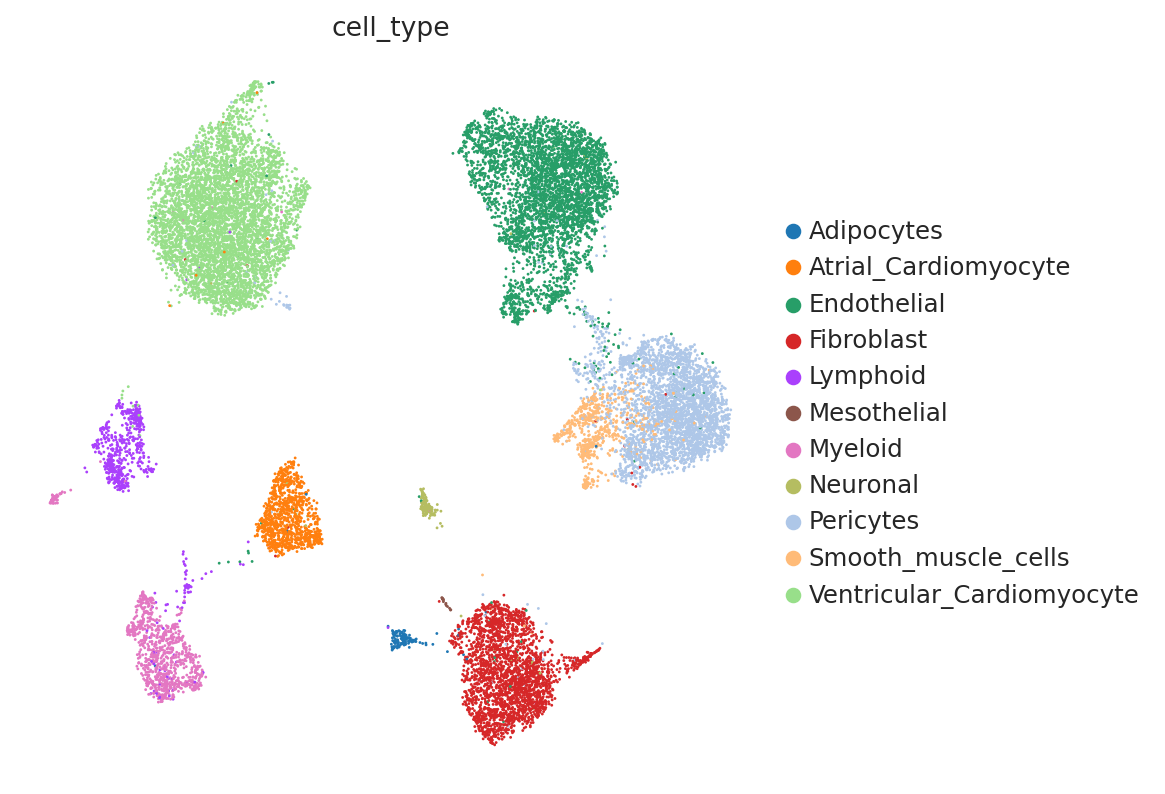

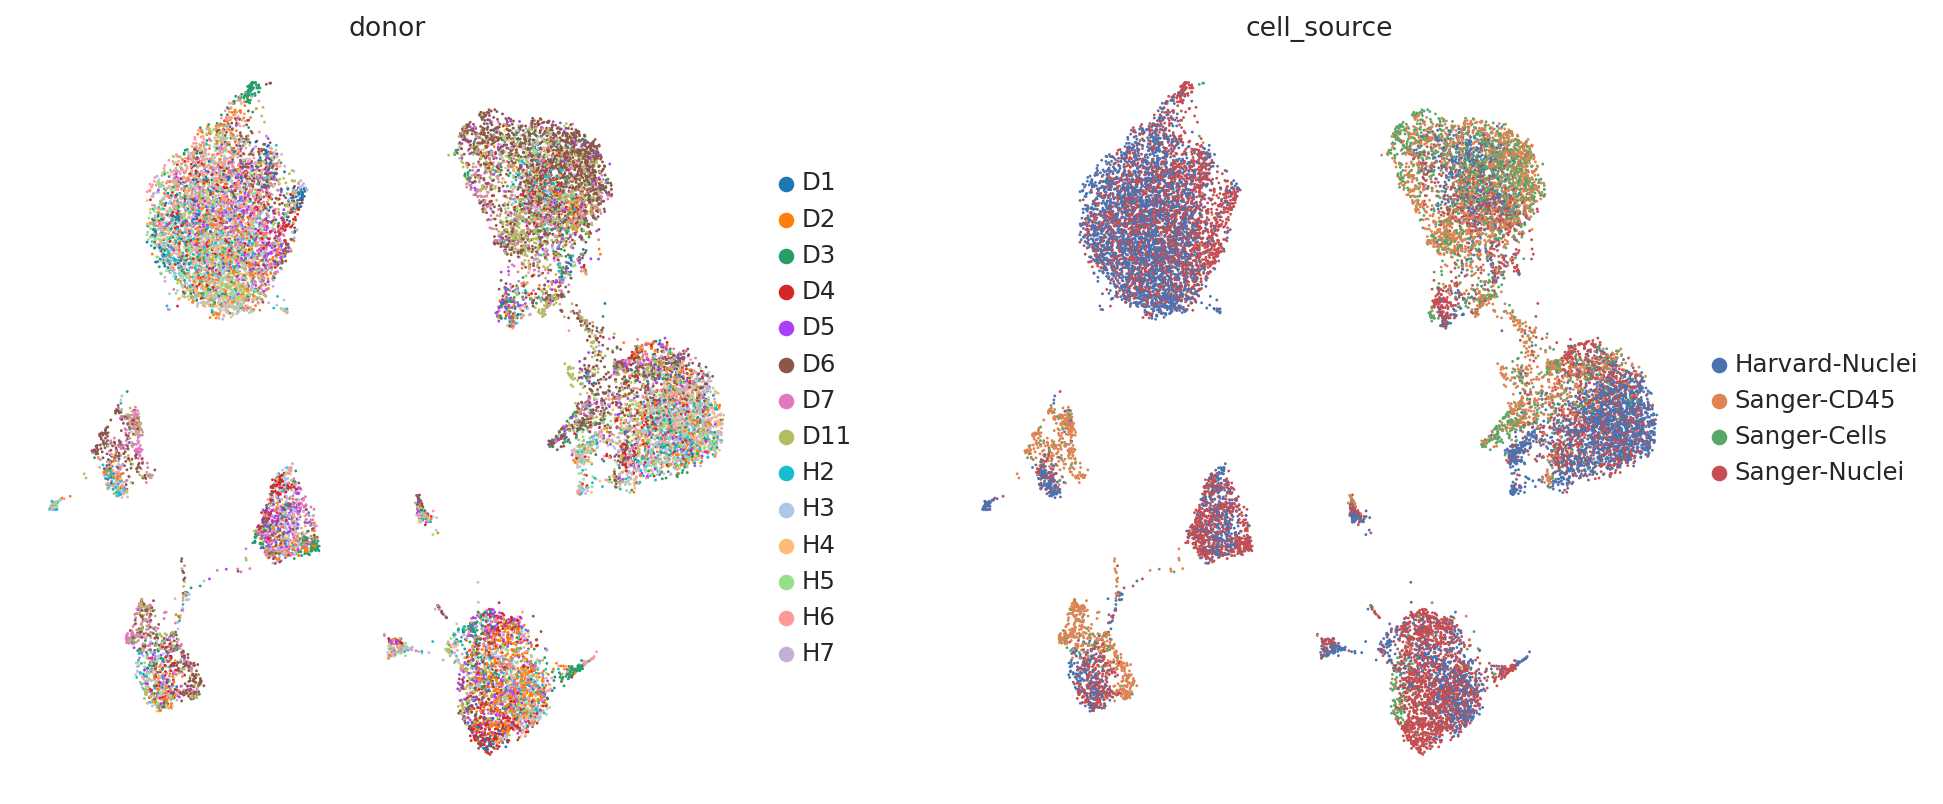

In [ ]:
# Clustering on the scVI latent space
### Above is downstream without scVI. Below uses scVI latent representation

sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
### No use of n_pcs : the graph is already constructed, so PCA is not needed
sc.tl.umap(adata, min_dist=0.3)
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
    save="_2_scvi_celltype.png"
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
    save="_3_scvi_donor_cellsource.png"
)

/tmp/ipython-input-4123875054.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)


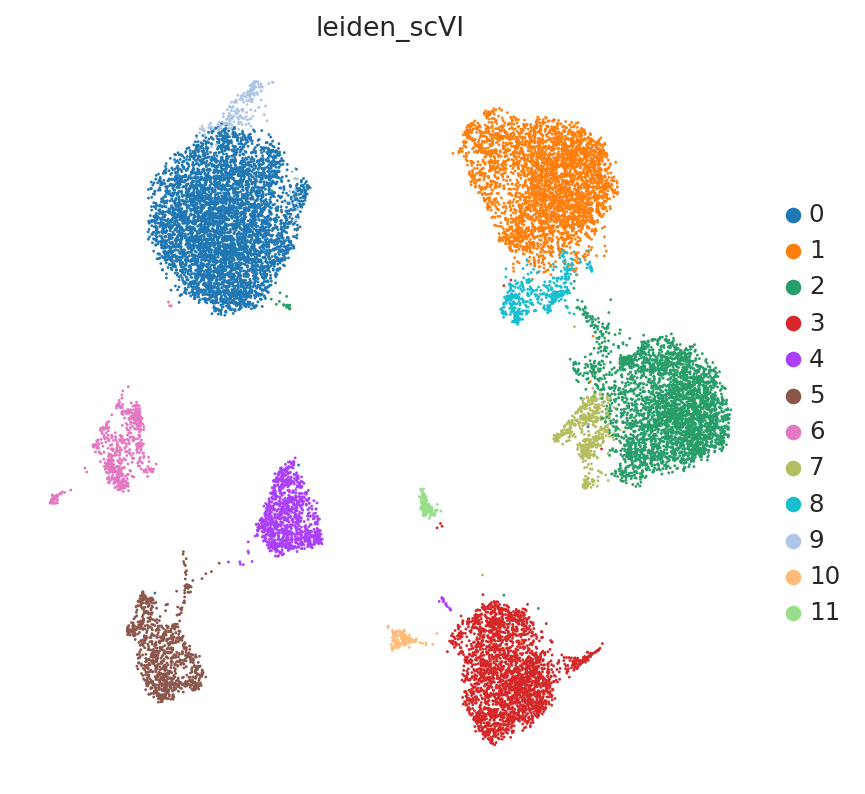

In [ ]:
# Clustering on the scVI latent space
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)
sc.pl.umap(
    adata,
    color=[SCVI_CLUSTERS_KEY],
    frameon=False,
    save="_4_scvi_leiden.png"
)

In [11]:
# Differential expression
### sc.tl.rank_genes_groups에서 하는 것과 같이, DEG extraction을 한다.
### scanpy와 다른 점은 scanpy는 wilcoxon과같은 linear statistical method를 쓰는반면 scVI는 latent space에서 봄

adata.obs.cell_type.head()

,cell_type
AACTCCCCACGAGAGT-1-HCAHeart7844001,Myeloid
ATAACGCAGAGCTGGT-1-HCAHeart7829979,Ventricular_Cardiomyocyte
GTCAAGTCATGCCACG-1-HCAHeart7702879,Fibroblast
GGTGATTCAAATGAGT-1-HCAHeart8102858,Endothelial
AGAGAATTCTTAGCAG-1-HCAHeart8102863,Endothelial


In [12]:
## One vs one DE test

de_df = model.differential_expression(
    groupby="cell_type", group1="Endothelial", group2="Fibroblast"
)
de_df.head()

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,proba_m2,bayes_factor,scale1,scale2,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,comparison,group1,group2
SOX17,0.9984,0.0016,6.436144,0.001671,0.000024,0.784371,0.006541,0.307617,0.004497,17.128260,0.185868,Endothelial vs Fibroblast,Endothelial,Fibroblast
EGFL7,0.9972,0.0028,5.875328,0.007569,0.000464,2.376779,0.036795,0.741543,0.025756,89.509659,1.171088,Endothelial vs Fibroblast,Endothelial,Fibroblast
VWF,0.9964,0.0036,5.623212,0.016753,0.000548,5.072563,0.054375,0.808226,0.032298,169.696747,2.210197,Endothelial vs Fibroblast,Endothelial,Fibroblast
PECAM1,0.9954,0.0046,5.377086,0.005488,0.000734,2.065984,0.075634,0.653930,0.054374,60.615467,3.404959,Endothelial vs Fibroblast,Endothelial,Fibroblast
CD74,0.9940,0.0060,5.109976,0.010696,0.000258,4.363627,0.039657,0.676320,0.024939,100.406143,1.076979,Endothelial vs Fibroblast,Endothelial,Fibroblast


In [13]:
# One vs all test

de_df = model.differential_expression(groupby="cell_type", mode="change")
de_df.head()

DE...:   0%|          | 0/11 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
ADIPOQ,0.9986,0.0014,6.569875,0.003693,0.000056,0.00001,0.25,7.458161,7.107312,3.072347,...,2.324136,0.003622,0.593103,0.003352,33.367058,0.217771,True,Adipocytes vs Rest,Adipocytes,Rest
PLIN1,0.9982,0.0018,6.318161,0.004430,0.000046,0.00001,0.25,7.302711,7.279441,2.444487,...,2.799999,0.004379,0.806897,0.004325,52.928783,0.196497,True,Adipocytes vs Rest,Adipocytes,Rest
GPAM,0.9970,0.0030,5.806135,0.024848,0.000195,0.00001,0.25,7.310909,7.303371,2.455405,...,17.372416,0.035791,0.896552,0.031520,280.354523,1.566094,True,Adipocytes vs Rest,Adipocytes,Rest
PTPRF,0.9968,0.0032,5.741396,0.003164,0.000098,0.00001,0.25,5.599347,5.640069,2.008295,...,1.468965,0.011300,0.600000,0.010651,26.619722,0.438295,True,Adipocytes vs Rest,Adipocytes,Rest
DGAT2,0.9966,0.0034,5.680571,0.003533,0.000037,0.00001,0.25,6.667113,6.848868,2.354062,...,2.682757,0.005028,0.593103,0.004866,43.615234,0.194146,True,Adipocytes vs Rest,Adipocytes,Rest


In [14]:
# Extract top markers from each cluster using DE results

markers = {}
cats = adata.obs.cell_type.cat.categories
for c in cats:
  cid = f"{c} vs Rest"
  cell_type_df = de_df.loc[de_df.comparison  == cid]
  cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0]
  ### positive log fc
  cell_type_df = cell_type_df[cell_type_df["bayes_factor"] > 3]
  ### statistically meaningful evidence : bf > 3
  cell_type_df = cell_type_df[cell_type_df["non_zeros_proportion1"] > 0.1]
  ### keeping genes that are expressed in at least 10% of cells in that group
  markers[c] = cell_type_df.index.tolist()[:3]
  ### get top 3 genes post filtering

In [17]:
markers

{'Adipocytes': ['ADIPOQ', 'PLIN1', 'GPAM'],
 'Atrial_Cardiomyocyte': ['SYNPR', 'MYL7', 'MYH6'],
 'Endothelial': ['EGFL7', 'PECAM1', 'VWF'],
 'Fibroblast': ['MEG3', 'CDH19', 'SRPX'],
 'Lymphoid': ['CD2', 'RUNX3', 'PTPRC'],
 'Mesothelial': ['ITLN1', 'MSLN', 'UPK3B'],
 'Myeloid': ['MS4A6A', 'SPI1', 'MS4A4A'],
 'Neuronal': ['GPM6B', 'NRXN1', 'CHL1'],
 'Pericytes': ['HIGD1B', 'CPE', 'RGS5'],
 'Smooth_muscle_cells': ['MYH11', 'WFDC1', 'ACTA2'],
 'Ventricular_Cardiomyocyte': ['C15orf41', 'GALNT17', 'AC013640.1']}

In [18]:
sc.tl.dendrogram(adata, groupby="cell_type", use_rep="X_scVI")

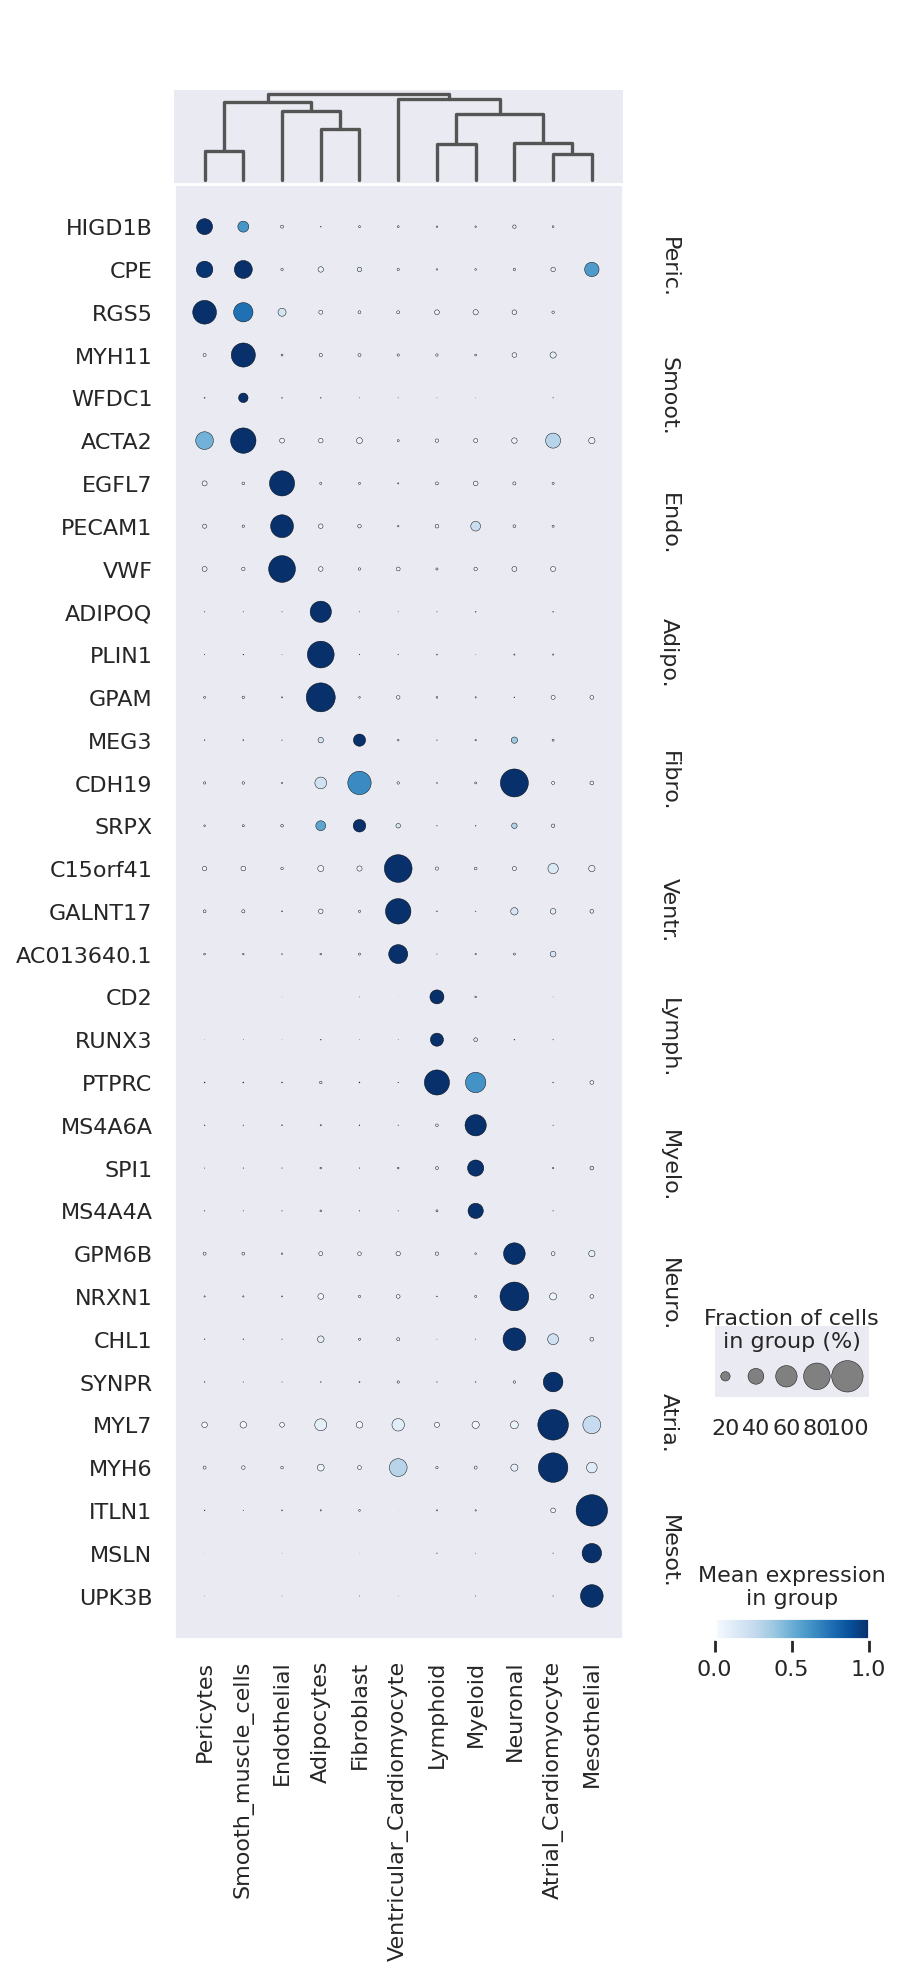

In [19]:
sc.pl.dotplot(
    adata,
    markers,
    groupby="cell_type",
    dendrogram=True,
    color_map="Blues",
    swap_axes=True,
    use_raw=True,
    standard_scale="var",
    save="_5_dotplot.png"
)

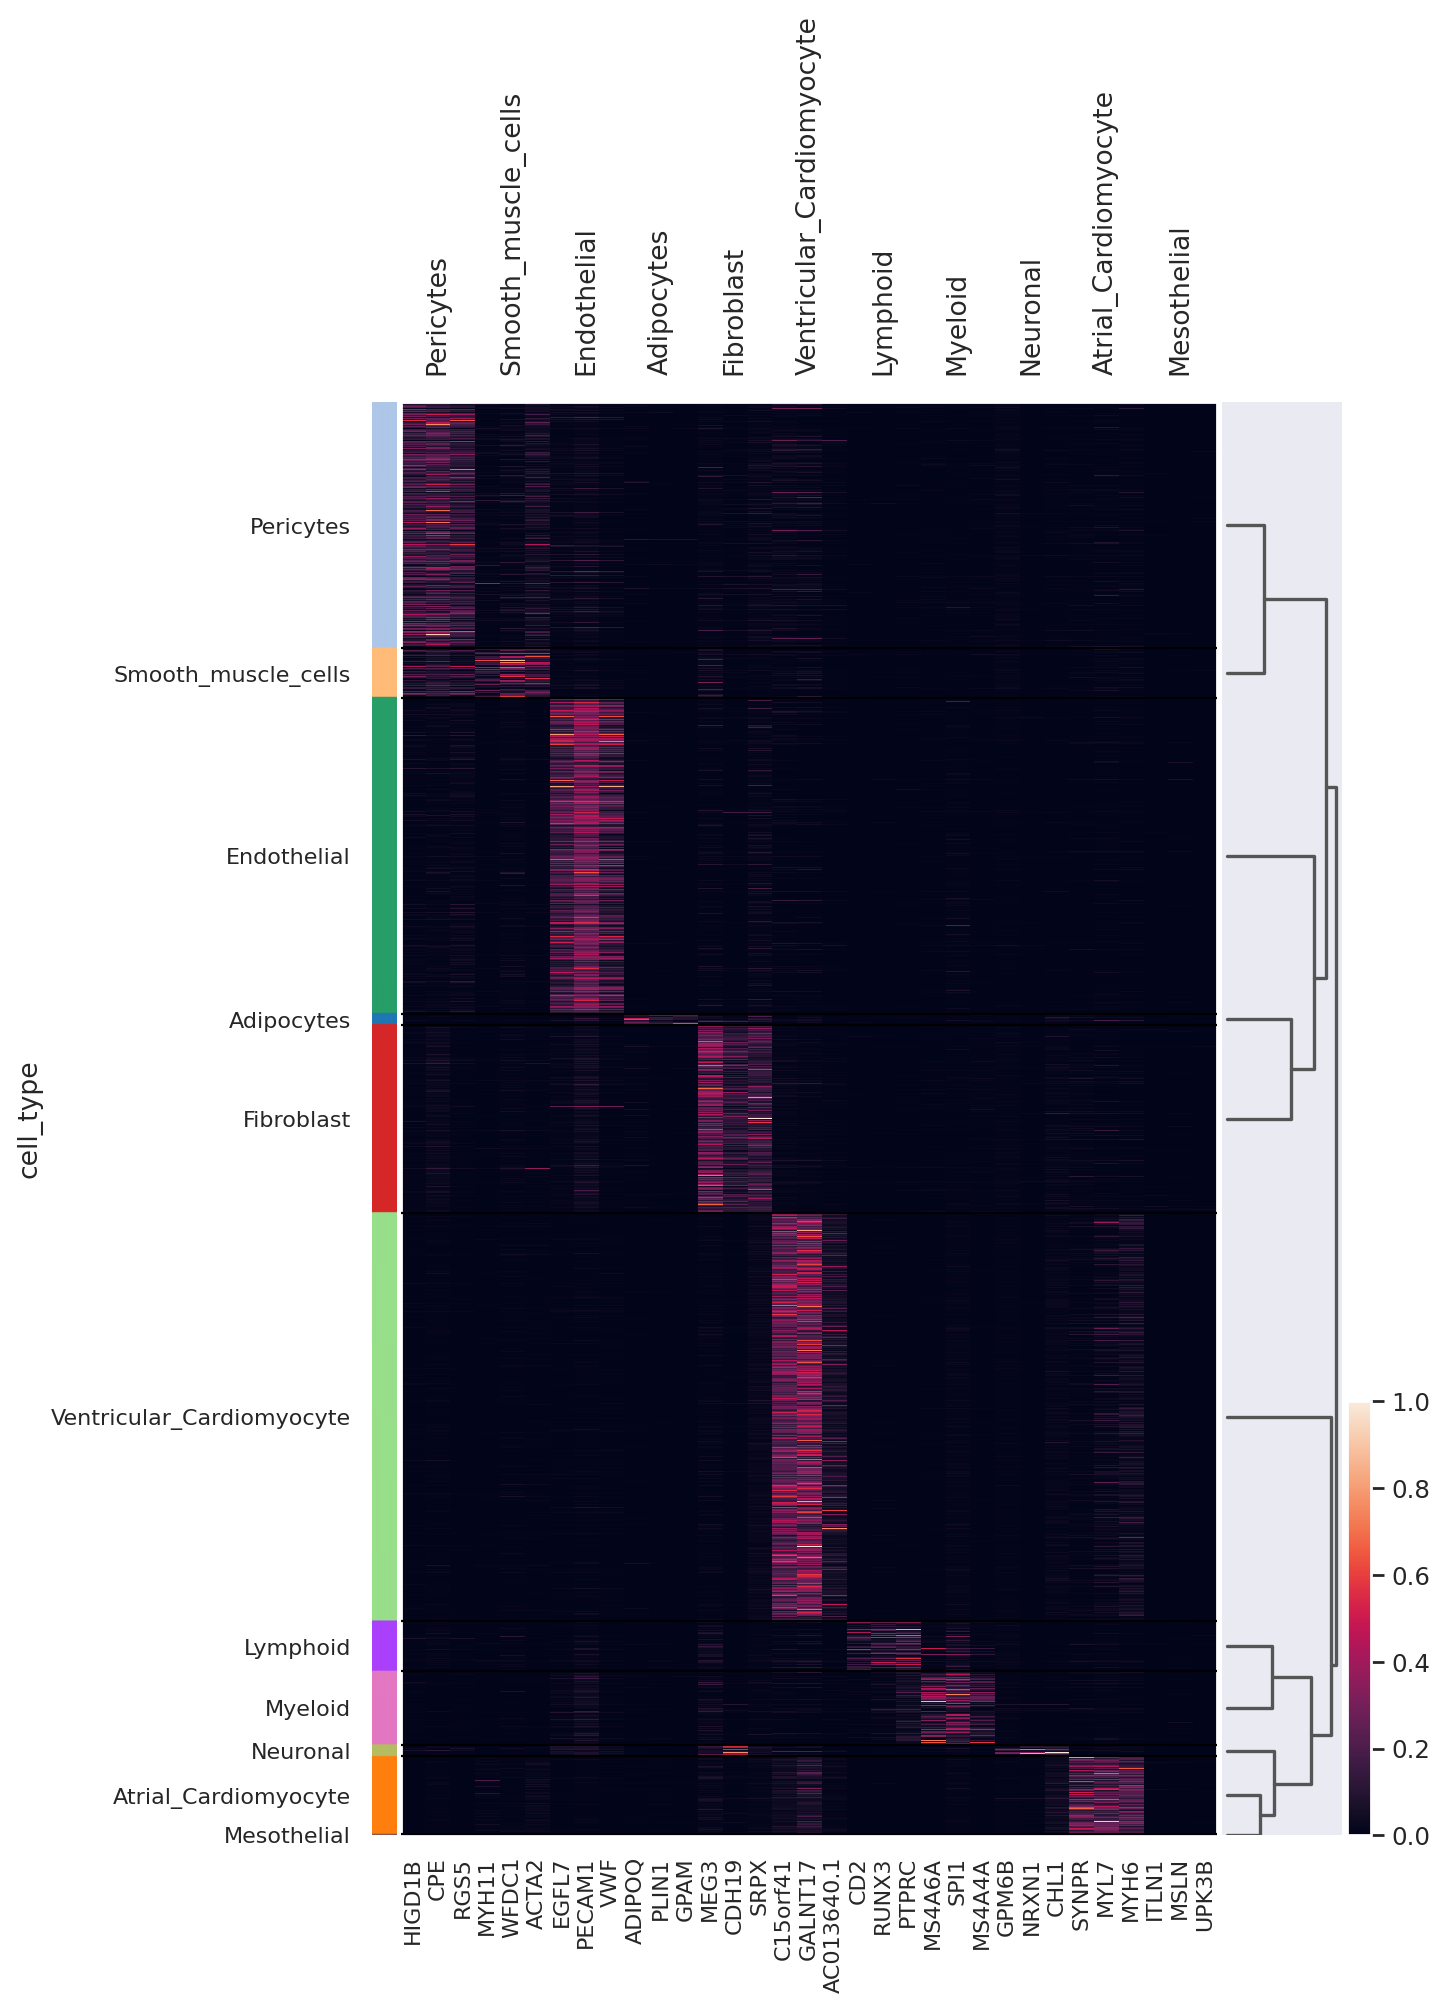

In [20]:
sc.pl.heatmap(
    adata,
    markers,
    groupby="cell_type",
    layer="scvi_normalized",
    standard_scale="var",
    dendrogram=True,
    figsize=(8, 12),
    save="_6_heatmap.png"
)